In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [12]:
df=pd.read_csv("abc.csv")

In [13]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [14]:
x=df.drop('years of Experience',axis=1)

KeyError: "['years of Experience'] not found in axis"

In [16]:
x=df.drop('Education Level',axis=1)

In [17]:
x

,Age,Gender,Job Title,Years of Experience,Salary
0,32.0,Male,Software Engineer,5.0,90000.0
1,28.0,Female,Data Analyst,3.0,65000.0
2,45.0,Male,Senior Manager,15.0,150000.0
3,36.0,Female,Sales Associate,7.0,60000.0
4,52.0,Male,Director,20.0,200000.0
...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Director of Operations,19.0,170000.0
372,29.0,Female,Junior Project Manager,2.0,40000.0
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0


In [18]:
y=df['Education Level']

In [19]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [22]:
X=df[['Age','Salary']]
y=df['Education Level']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [45]:
import numpy as np

In [46]:
mask = ~y_train.isnull()

X_train = X_train[mask]
y_train = y_train[mask]

In [47]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
y_pred=logreg.predict(X_test)

In [49]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[48  4  1]
 [19  4 12]
 [ 0  5  1]]


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.5638297872340425
Precision: 0.3651795965228801
Recall: 0.3955375861036239


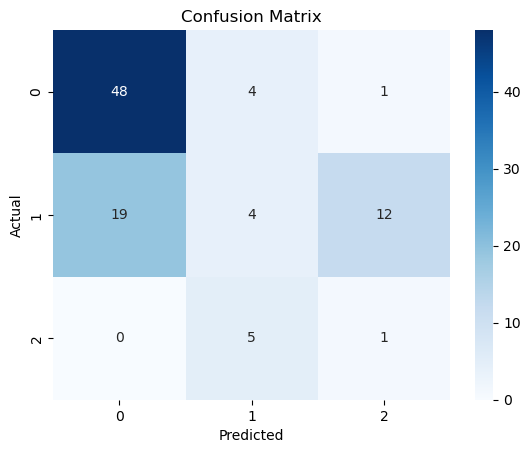

In [53]:
sns.heatmap(cm,annot=True,fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [54]:
x=np.linspace(-10,10,100)
y=1/(1+np.exp(-x))

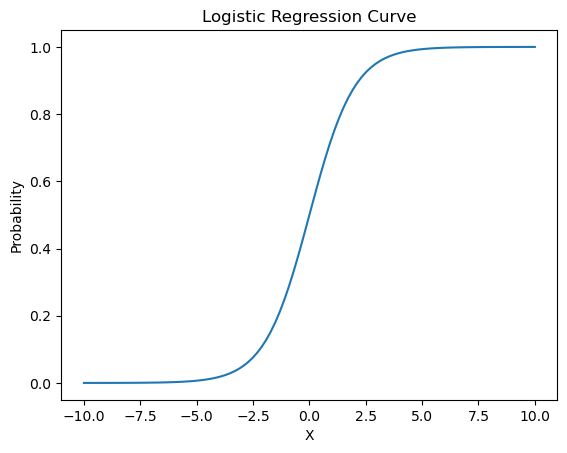

In [55]:
plt.plot(x,y)
plt.title("Logistic Regression Curve")
plt.xlabel("X")
plt.ylabel("Probability")
plt.show()